In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [39]:
import warnings
warnings.filterwarnings('ignore')

In [40]:
df=pd.read_csv('data/data-2.csv')

In [41]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [42]:
df.loc[:, ~df.columns.str.contains('^Unnamed')]

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [43]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

In [44]:
df.shape

(569, 33)

In [45]:
df['diagnosis'].unique()

array(['M', 'B'], dtype=object)

In [46]:
df['diagnosis'].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

Encoding diagnosis columns using the lambda function.......

In [47]:
df['diagnosis']=df['diagnosis'].apply(lambda x: 1 if x=='M' else 0)

In [48]:
df['diagnosis'].value_counts()

diagnosis
0    357
1    212
Name: count, dtype: int64

In [49]:
df=df.drop(columns=['id','Unnamed: 32'],axis=1)

In [50]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


No duplicate row,columns here and also no missing value here 

In [51]:
df.isnull().sum()

diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

In [52]:
df.duplicated().sum()

np.int64(0)

In [53]:
df.columns[df.columns.duplicated()].tolist()

[]

In [54]:
outlier_columns=[col for col in df.columns if 'radius' in col or 'perimeter' in col or 'area' in col]
outlier_columns

['radius_mean',
 'perimeter_mean',
 'area_mean',
 'radius_se',
 'perimeter_se',
 'area_se',
 'radius_worst',
 'perimeter_worst',
 'area_worst']

In [55]:
outlier_report = {}

In [56]:
for col in outlier_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    df[col] = df[col].clip(lower=lower, upper=upper)
    outlier_report[col] = {'Q1': round(Q1,2), 'Q3': round(Q3,2),
                           'IQR': round(IQR,2), 'Lower': round(lower,2),
                           'Upper': round(upper,2), 'Capped': int(n_out)}
    print(f"  {col}: {n_out} outliers capped  [lower={lower:.2f}, upper={upper:.2f}]")

  radius_mean: 14 outliers capped  [lower=5.58, upper=21.90]
  perimeter_mean: 13 outliers capped  [lower=31.78, upper=147.49]
  area_mean: 25 outliers capped  [lower=-123.30, upper=1326.30]
  radius_se: 38 outliers capped  [lower=-0.14, upper=0.85]
  perimeter_se: 38 outliers capped  [lower=-1.02, upper=5.98]
  area_se: 65 outliers capped  [lower=-23.16, upper=86.20]
  radius_worst: 17 outliers capped  [lower=4.34, upper=27.46]
  perimeter_worst: 15 outliers capped  [lower=22.17, upper=187.34]
  area_worst: 35 outliers capped  [lower=-337.75, upper=1937.05]


In [57]:
features = [
    'perimeter_mean',
    'area_mean',
    'perimeter_worst',
    'area_worst'
]

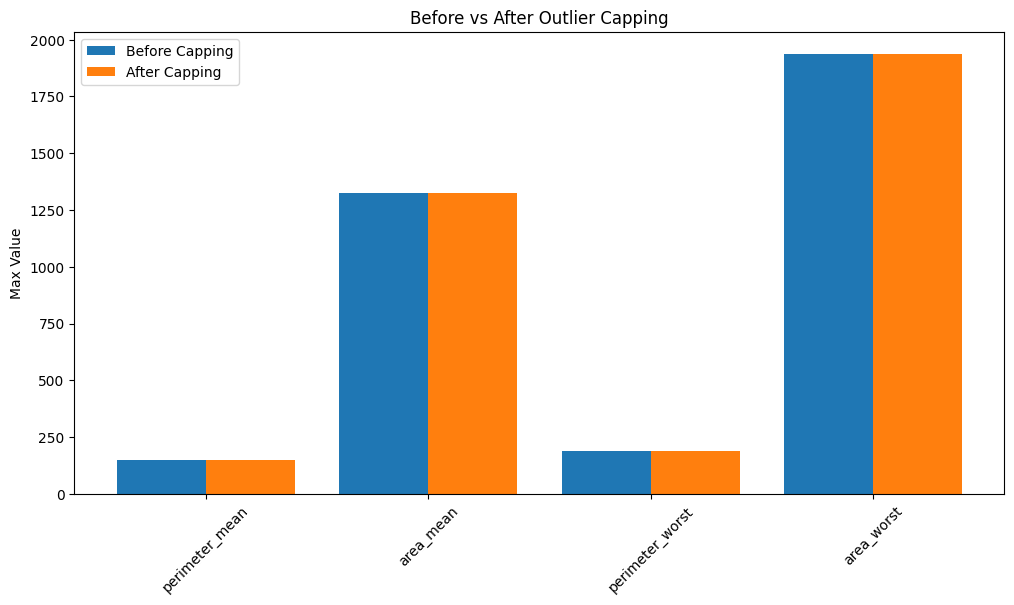

In [58]:
before_max = []
after_max = []

for col in features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    before_max.append(df[col].max())

    after_series = df[col].clip(lower, upper)
    after_max.append(after_series.max())

x = range(len(features))
plt.figure(figsize=(12,6))

plt.bar(x, before_max, width=0.4, label='Before Capping')
plt.bar([i + 0.4 for i in x], after_max, width=0.4, label='After Capping')

plt.xticks([i + 0.2 for i in x], features, rotation=45)

plt.title('Before vs After Outlier Capping')
plt.ylabel('Max Value')

plt.legend()

plt.show()

In [59]:
feature_cols = [c for c in df.columns if c != 'diagnosis']

In [60]:
data=df[feature_cols].corr()

<Axes: >

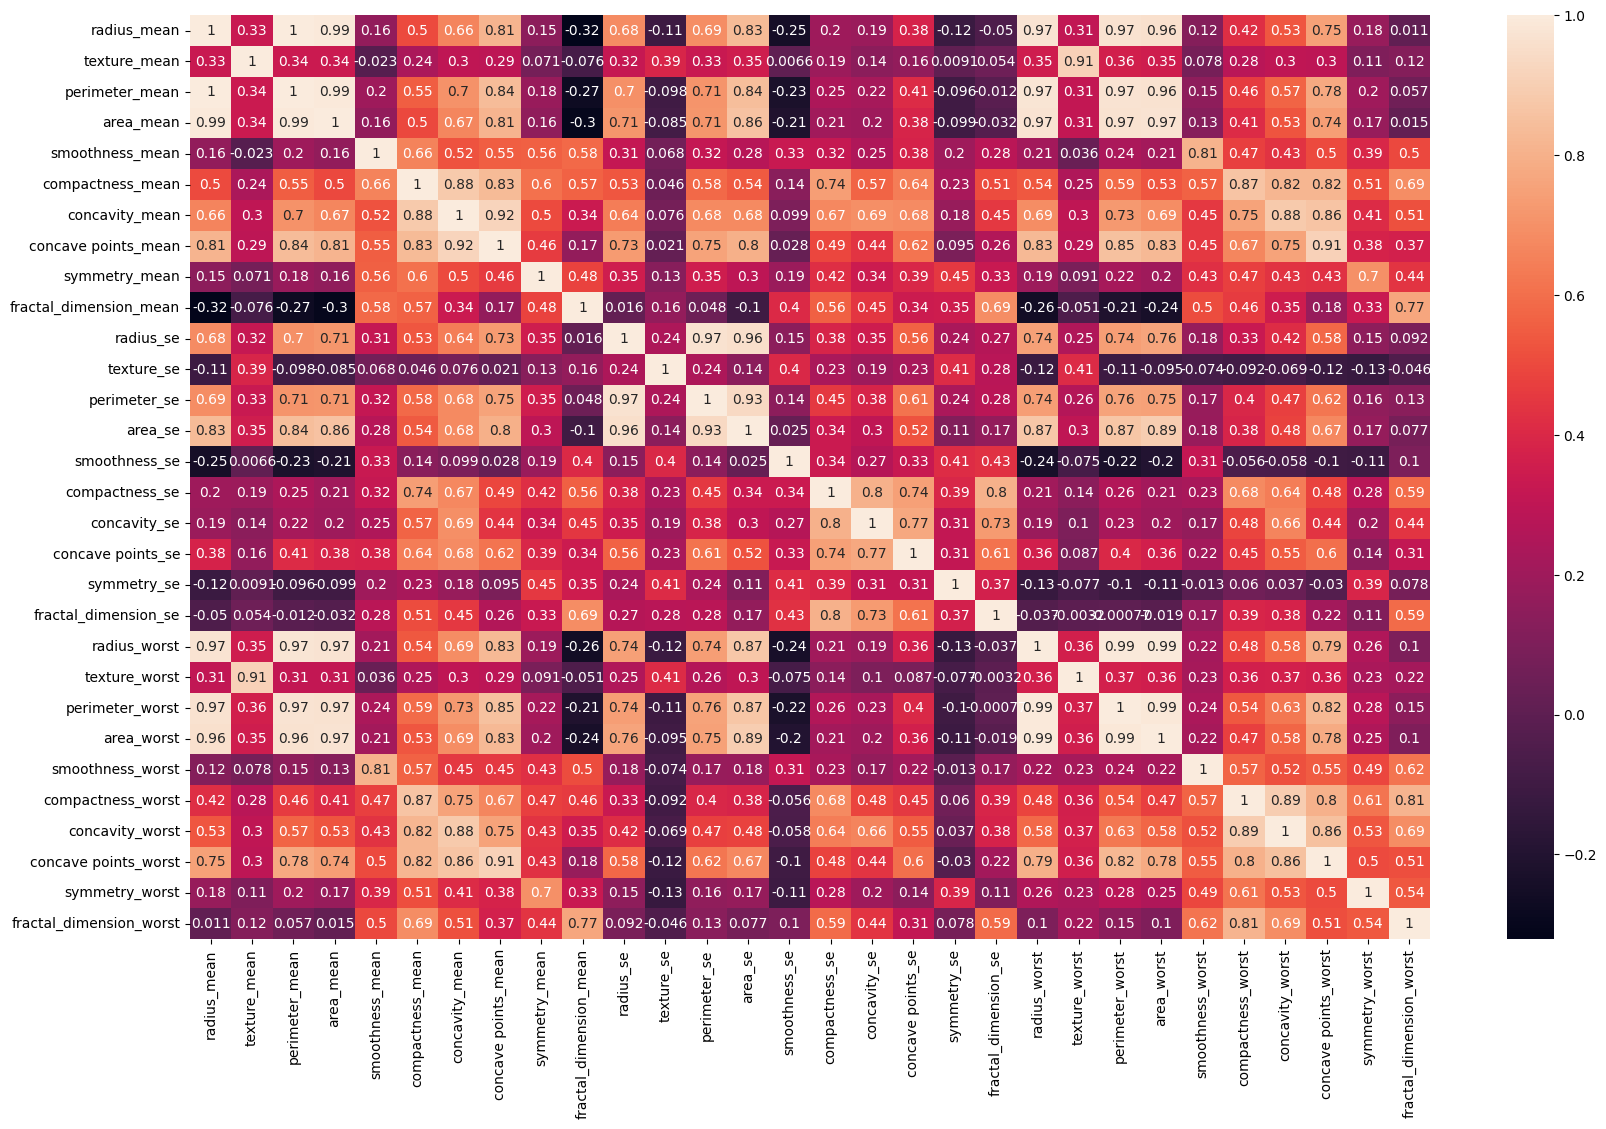

In [61]:
plt.figure(figsize=(20,12))
sns.heatmap(data=data,annot=True)

In [62]:
corr_mat=df[feature_cols].corr().abs()
upper_tri=corr_mat.where(np.triu(np.ones(corr_mat.shape),k=1).astype(bool))

In [63]:
corr_mat

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
radius_mean,1.000000,0.329311,0.997692,0.993891,0.160606,0.499849,0.661265,0.809433,0.148340,0.321139,...,0.973472,0.307002,0.967506,0.962549,0.119157,0.418388,0.530874,0.747817,0.177453,0.011394
texture_mean,0.329311,1.000000,0.335695,0.337728,0.023389,0.236702,0.302418,0.293464,0.071401,0.076437,...,0.353879,0.912045,0.361092,0.354332,0.077503,0.277830,0.301025,0.295316,0.105008,0.119205
perimeter_mean,0.997692,0.335695,1.000000,0.991861,0.197825,0.552132,0.701718,0.839424,0.183665,0.269567,...,0.974555,0.313410,0.973889,0.963900,0.150833,0.462254,0.569055,0.776769,0.203457,0.057259
area_mean,0.993891,0.337728,0.991861,1.000000,0.160500,0.496198,0.666371,0.810808,0.156786,0.303701,...,0.973784,0.312522,0.967206,0.973460,0.126092,0.407872,0.528346,0.739618,0.174991,0.014684
smoothness_mean,0.160606,0.023389,0.197825,0.160500,1.000000,0.659123,0.521984,0.553695,0.557775,0.584792,...,0.214804,0.036072,0.238936,0.214718,0.805324,0.472468,0.434926,0.503053,0.394309,0.499316
compactness_mean,0.499849,0.236702,0.552132,0.496198,0.659123,1.000000,0.883121,0.831135,0.602641,0.565369,...,0.539476,0.248133,0.591973,0.533815,0.565541,0.865809,0.816275,0.815573,0.510223,0.687382
concavity_mean,0.661265,0.302418,0.701718,0.666371,0.521984,0.883121,1.000000,0.921391,0.500667,0.336783,...,0.686863,0.299879,0.725661,0.688928,0.448822,0.754968,0.884103,0.861323,0.409464,0.514930
concave points_mean,0.809433,0.293464,0.839424,0.810808,0.553695,0.831135,0.921391,1.000000,0.462497,0.166917,...,0.829281,0.292752,0.853279,0.826567,0.452753,0.667454,0.752399,0.910155,0.375744,0.368661
symmetry_mean,0.148340,0.071401,0.183665,0.156786,0.557775,0.602641,0.500667,0.462497,1.000000,0.479921,...,0.192310,0.090651,0.224258,0.200667,0.426675,0.473200,0.433721,0.430297,0.699826,0.438413
fractal_dimension_mean,0.321139,0.076437,0.269567,0.303701,0.584792,0.565369,0.336783,0.166917,0.479921,1.000000,...,0.255592,0.051269,0.208299,0.238052,0.504942,0.458798,0.346234,0.175325,0.334019,0.767297


In [64]:
high_corr_pairs = [(col, upper_tri[col].idxmax(), upper_tri[col].max()) 
                   for col in upper_tri.columns if upper_tri[col].max() > 0.95]


In [65]:
high_corr_pairs

[('perimeter_mean', 'radius_mean', np.float64(0.9976917749925795)),
 ('area_mean', 'radius_mean', np.float64(0.9938914327232276)),
 ('perimeter_se', 'radius_se', np.float64(0.9672018341287665)),
 ('area_se', 'radius_se', np.float64(0.9573459204034018)),
 ('radius_worst', 'perimeter_mean', np.float64(0.9745554496010718)),
 ('perimeter_worst', 'radius_worst', np.float64(0.9936627422103224)),
 ('area_worst', 'radius_worst', np.float64(0.9931980672359785))]

In [66]:
drop_col=set()
for col1,col2,val in high_corr_pairs:
    print(f"High relation :{col1} and {col2} ={val :.3f} drop {col2}")
    drop_col.add(col2)
df.drop(columns=drop_col,axis=1,inplace=True)    

High relation :perimeter_mean and radius_mean =0.998 drop radius_mean
High relation :area_mean and radius_mean =0.994 drop radius_mean
High relation :perimeter_se and radius_se =0.967 drop radius_se
High relation :area_se and radius_se =0.957 drop radius_se
High relation :radius_worst and perimeter_mean =0.975 drop perimeter_mean
High relation :perimeter_worst and radius_worst =0.994 drop radius_worst
High relation :area_worst and radius_worst =0.993 drop radius_worst


In [67]:
print(f"Dropped {len(drop_col)} highly correlated features.")


Dropped 4 highly correlated features.


In [68]:
df.shape

(569, 27)

<Axes: >

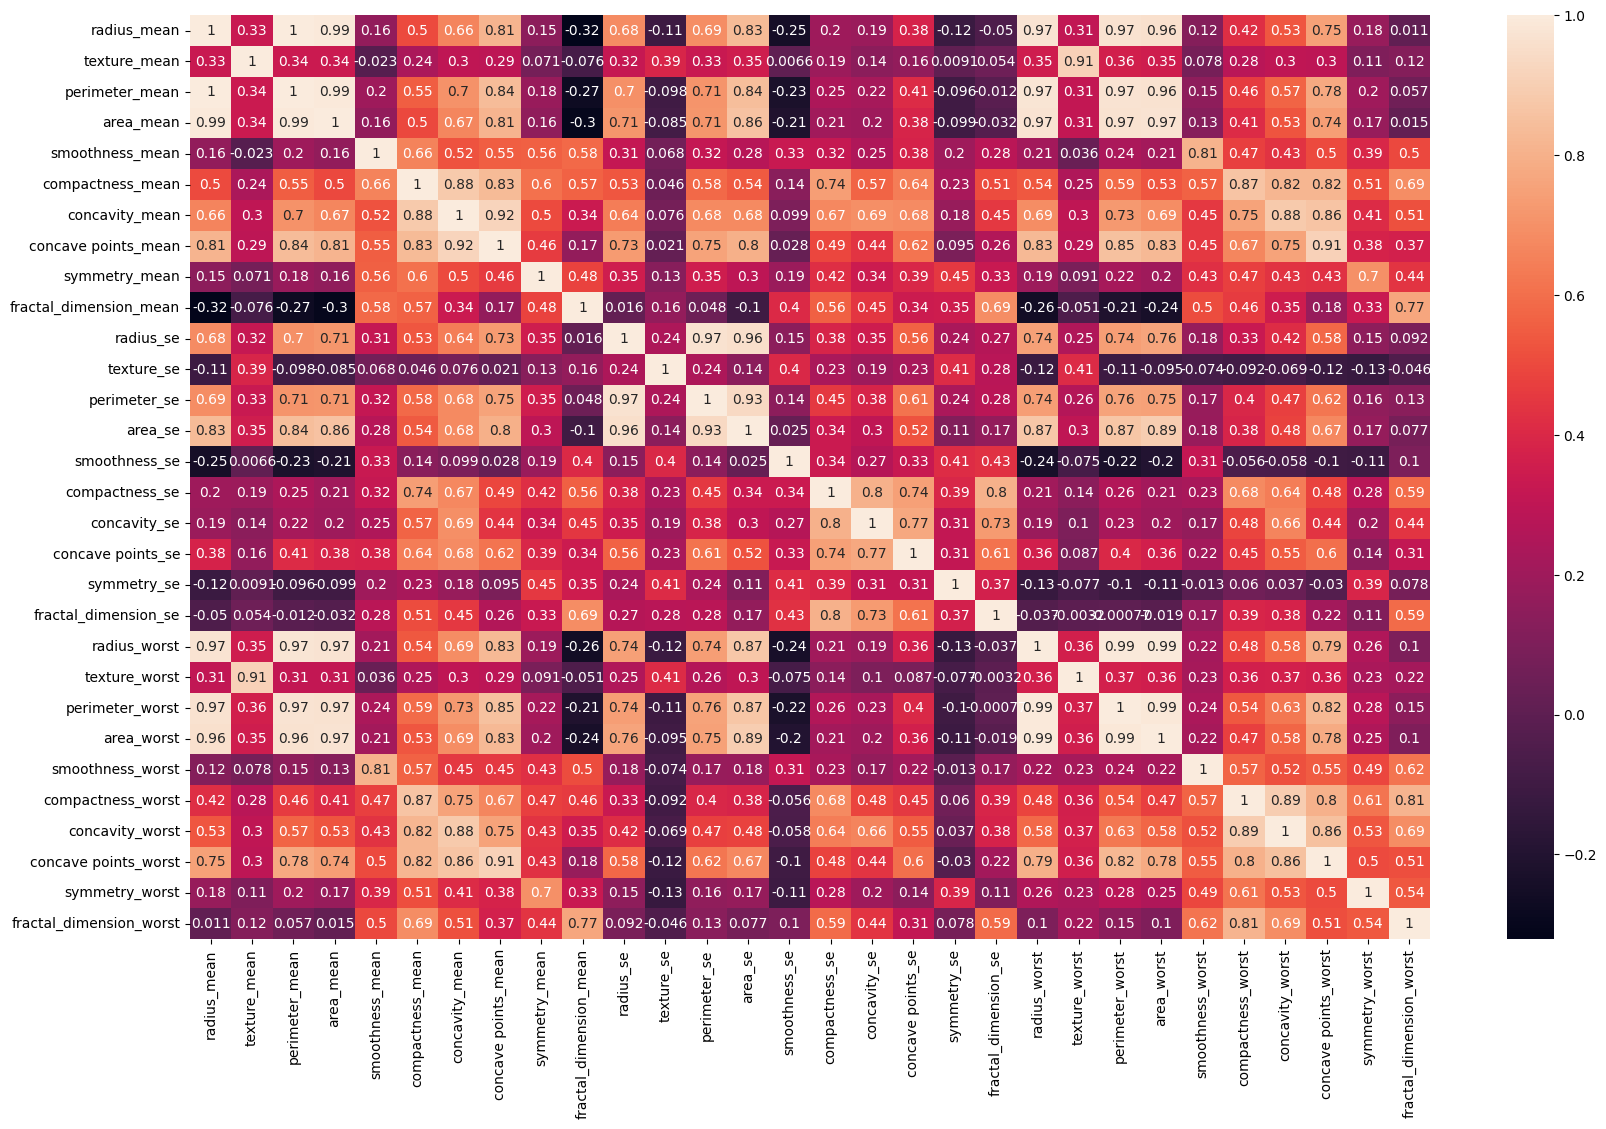

In [69]:
plt.figure(figsize=(20,12))
sns.heatmap(data=data,annot=True)

In [70]:
df.columns

Index(['diagnosis', 'texture_mean', 'area_mean', 'smoothness_mean',
       'compactness_mean', 'concavity_mean', 'concave points_mean',
       'symmetry_mean', 'fractal_dimension_mean', 'texture_se', 'perimeter_se',
       'area_se', 'smoothness_se', 'compactness_se', 'concavity_se',
       'concave points_se', 'symmetry_se', 'fractal_dimension_se',
       'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

In [71]:
df.to_csv('data/preprocessed_data.csv',index=False)

In [72]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [74]:
feature_cols = [c for c in df.columns if c != 'diagnosis']

In [75]:
df[feature_cols] = scaler.fit_transform(df[feature_cols])
df[feature_cols]

,texture_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,texture_se,perimeter_se,...,fractal_dimension_se,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,-2.073335,1.184085,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,-0.565265,2.343091,...,0.907083,-1.359293,2.439568,2.287627,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,-0.353632,2.249396,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,-0.876244,0.498609,...,-0.099444,-0.369203,1.631542,2.287627,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,0.456187,1.846217,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,-0.780083,1.345409,...,0.293559,-0.023974,1.434234,1.807751,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,0.253732,-0.831485,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,-0.110409,0.532139,...,2.047511,0.133984,-0.245395,-0.593838,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,-1.151816,2.154338,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,-0.790244,1.953934,...,0.499328,-1.466770,1.424838,1.525780,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,0.721473,2.250380,1.041842,0.219060,1.947285,2.320965,-0.312589,-0.931027,0.071025,2.343091,...,0.167980,0.117700,1.860170,2.287627,0.378365,-0.273318,0.664512,1.629151,-1.360158,-0.709091
565,2.085134,2.036334,0.102458,-0.017833,0.693043,1.263669,-0.217664,-1.058611,2.260938,1.786287,...,-0.490556,2.047399,1.512531,1.854045,-0.691230,-0.394820,0.236573,0.733827,-0.531855,-0.973978
566,2.045574,0.715676,-0.840484,-0.038680,0.046588,0.105777,-0.809117,-0.895587,-0.257371,0.517871,...,0.036727,1.374854,0.626208,0.576760,-0.809587,0.350735,0.326767,0.414069,-1.104549,-0.318409
567,2.336457,2.049446,1.525767,3.272144,3.296944,2.658866,2.137194,1.043695,0.686088,2.192208,...,0.904057,2.237926,2.439568,2.043428,1.430427,3.904848,3.197605,2.289985,1.919083,2.219635
